In [1]:
import pandas as pd

# Read in some real data
pokemon = pd.read_csv('pokedata_num.csv')
pokemon.head()

,pokedex,name,hp,attack,defense,special_attack,special_defense,speed,is_evolved
0,1,Bulbasaur,45,49,49,65,65,45,0
1,2,Ivysaur,60,62,63,80,80,60,1
2,3,Venusaur,80,82,83,100,100,80,1
3,4,Charmander,39,52,43,60,50,65,0
4,5,Charmeleon,58,64,58,80,65,80,1


In [2]:
import numpy as np

# Suppose we are interested in modeling the MAXIMUM value of a Pokemon's hp
poke_hp = pokemon.hp
n = len(poke_hp) #sample size
print(n)
max_hp = np.max(poke_hp) #the MLE
print(max_hp)

809
255


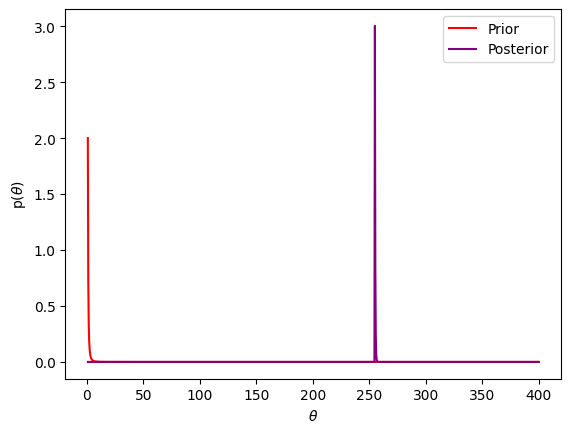

In [3]:
# We are assuming y|theta ~ Unif(0, theta)
# and that theta ~ Pareto(wedge, alpha)
# let's default wedge = 1 and alpha = 2 (both need to be > 0)

# Set up the prior distribution (Pareto)
def prior(theta, wedge=1, alpha=2):
    # note that the prior is only defined for theta >= wedge
    return np.where(theta >= wedge, ((alpha) * (wedge**alpha)) / (theta**(alpha + 1)), 0)

# We manually found the posterior (also Pareto), but now for n samples
# The prior should work fine (for small values of alpha) but when we bring in n we might have some overflow errors
# i.e. this won't work:
def bad_posterior(theta, max_y, n, wedge=1, alpha=2):
    alpha_star = alpha + n
    wedge_star = max(max_y, wedge)
    return np.where(theta >= wedge_star, ((alpha_star) * (wedge_star**alpha_star)) / (theta**(alpha_star + 1)), 0)

# Instead, we can use the log of the distribution for the calculation, and then convert it back to the original scale with e^log(.)
# this way we are not taking the exponent of very large values
def good_posterior(theta, max_y, n, wedge=1, alpha=2):
    alpha_star = alpha + n
    wedge_star = max(max_y, wedge)

    log_post = np.where(theta >= wedge_star,
                        np.log(alpha_star) + alpha_star * np.log(wedge_star) - (alpha_star + 1) * np.log(theta),
                        -np.inf) # because log(0) = -infinity
    
    return np.exp(log_post)


import matplotlib.pyplot as plt
# Generate the plot
sim_theta = np.linspace(1, 400, 1000)
prior_dist = prior(sim_theta)
post_dist = good_posterior(sim_theta, max_y=max_hp, n = n)

plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();

In [4]:
# While I didn't state it in the slides, the expected value of the Pareto is only defined for alpha > 1:
# E(theta) = alpha*wedge/(alpha - 1)

# SO, the prior mean:
prior_mean = 2*1/(2-1)
# the MLE is just the maximum:
MLE = max_hp
# and the posterior mean:
posterior_mean = (2 + n)*(max(max_hp, 1))/(2 + n - 1)
print(prior_mean)
print(MLE)
print(posterior_mean)

2.0
255
255.3148148148148


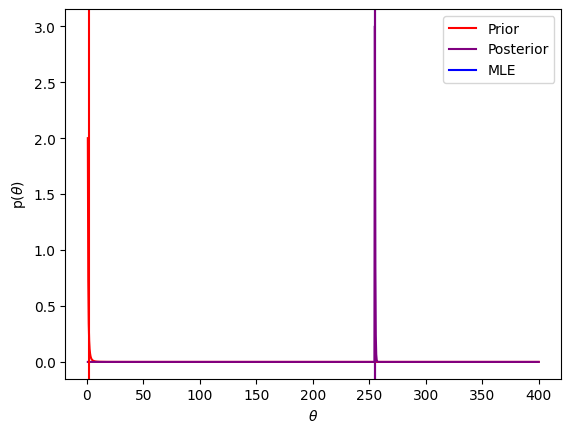

In [5]:
plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.axvline(x=prior_mean, color = 'red')
plt.axvline(x=MLE, color = 'blue', label = 'MLE')
plt.axvline(x=posterior_mean, color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();

In [5]:
# This looks a little bit more interesting if we assume we have less data
# What if we only had the first 10 pokemon?
sub_poke = pokemon.iloc[:10,:]
sub_poke

,pokedex,name,hp,attack,defense,special_attack,special_defense,speed,is_evolved
0,1,Bulbasaur,45,49,49,65,65,45,0
1,2,Ivysaur,60,62,63,80,80,60,1
2,3,Venusaur,80,82,83,100,100,80,1
3,4,Charmander,39,52,43,60,50,65,0
4,5,Charmeleon,58,64,58,80,65,80,1
5,6,Charizard,78,84,78,109,85,100,1
6,7,Squirtle,44,48,65,50,64,43,0
7,8,Wartortle,59,63,80,65,80,58,1
8,9,Blastoise,79,83,100,85,105,78,1
9,10,Caterpie,45,30,35,20,20,45,0


In [6]:
poke_hp = sub_poke.hp
n = len(poke_hp) #sample size
print(n)
max_hp = np.max(poke_hp) #the MLE
print(max_hp)

10
80


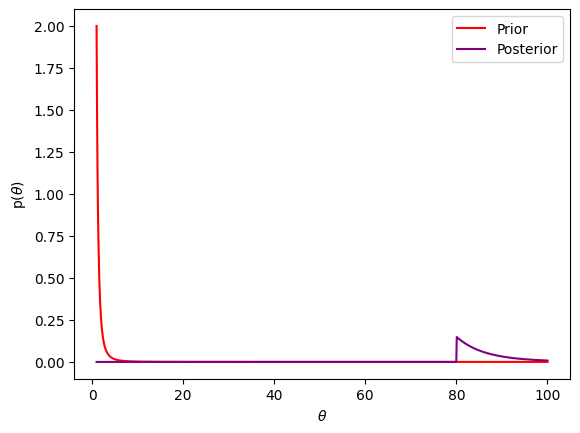

In [7]:
sim_theta = np.linspace(1, 100, 1000)
prior_dist = prior(sim_theta)
post_dist = good_posterior(sim_theta, max_y=max_hp, n = n)

plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();

In [8]:
# estimates (note I'm still using alpha = 2 and wedge = 1)
prior_mean = 2*1/(2-1)
MLE = max_hp
posterior_mean = (2 + n)*(max(max_hp, 1))/(2 + n - 1)
print(prior_mean)
print(MLE)
print(posterior_mean)

2.0
80
87.27272727272727


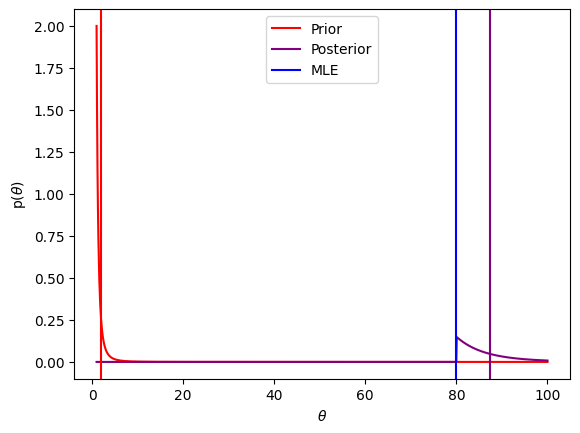

In [9]:
plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.axvline(x=prior_mean, color = 'red')
plt.axvline(x=MLE, color = 'blue', label = 'MLE')
plt.axvline(x=posterior_mean, color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();

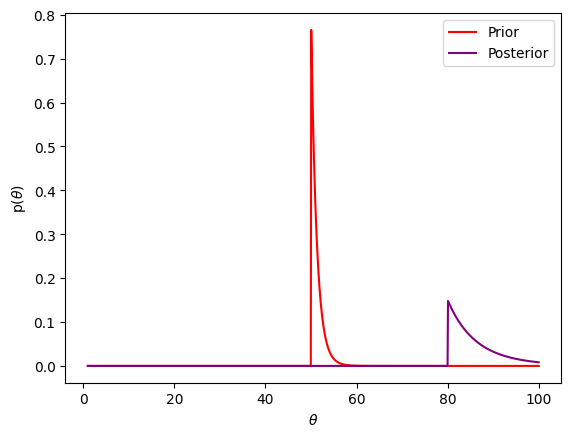

In [14]:
# What if I change the priors?
# I'll still use wedge = 1 (since I know that Pokemon HP can't go below 1)
# But let's use a larger wedge, say 50
# We'll keep alpha = 2
# Note: technically, you could use alpha <= 1, but that means the prior mean is infinite (can't plot that)
prior_dist = prior(sim_theta, wedge = 50, alpha = 40)
post_dist = good_posterior(sim_theta, max_y=max_hp, n = n)

plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();

In [15]:
prior_mean = (40*50)/(40-1)
MLE = max_hp
posterior_mean = (40 + n)*(max(max_hp, 50))/(40 + n - 1)
print(prior_mean)
print(MLE)
print(posterior_mean)

51.282051282051285
80
81.63265306122449


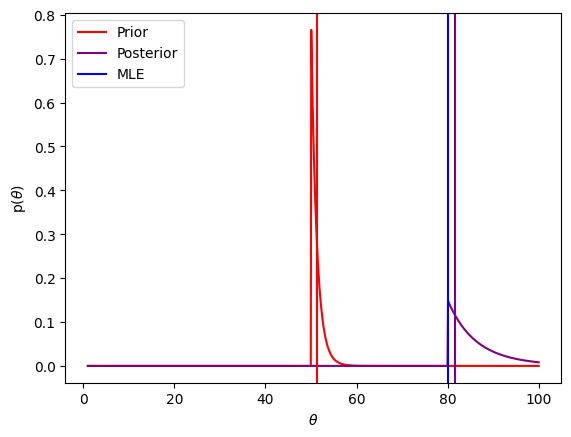

In [16]:
plt.plot(sim_theta, prior_dist, label = 'Prior', color = 'red')
plt.plot(sim_theta, post_dist, label = 'Posterior', color = 'purple')
plt.axvline(x=prior_mean, color = 'red')
plt.axvline(x=MLE, color = 'blue', label = 'MLE')
plt.axvline(x=posterior_mean, color = 'purple')
plt.xlabel(r'$\theta$')
plt.ylabel(r'p($\theta$)')
plt.legend()
plt.show();